# 09-Decoupled Systems & Two-Tier Architecture

In Lessons 01 and 02, we built Monolithic applications. A monolith means the User Interface (Streamlit) and the Neural Network Engine (PyTorch) are running inside the exact same Python process, on the exact same physical server.

For a Jupyter Notebook or a local prototype, this is fine. But for an Enterprise deployment, **a Monolith is an architectural disaster.**

* **Compute Waste**: GPUs cost $3.00+ per hour. Serving HTML and handling UI button clicks only requires a cheap $0.05/hour CPU. If your UI and Model are trapped on the same machine, you are paying GPU prices to render CSS.
* **Scaling Mismatch**: If a viral post drives 10,000 users to your site, the UI needs to scale up instantly. But if the UI is bolted to a 70B parameter LLM, scaling up the server requires copying the 140GB model into VRAM 10,000 times. The cluster will collapse.

To survive in production, we must mathematically sever the UI from the Brain. This is called a **Decoupled Two-Tier Architecture**.

Let's set up our Python environment to engineer the HTTP bridge between two completely independent servers.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import requests
import json
import time

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Engineering & Networking Environment Ready.")

✅ Systems Engineering & Networking Environment Ready.


# 1. The Physics of the Network Bridge

In a Decoupled System, the Streamlit server contains absolutely zero PyTorch code. It does not know what a Tensor is. It has no GPU.

Instead, the Streamlit server acts as an **HTTP Client**. When a user types a prompt into the UI, Streamlit packages that string into a JSON payload and fires it across the network to the internal IP address of the FastAPI Backend.

This introduces a new physics equation to our system: **Network Latency ($L_{net}$)**.


$$Total Time = L_{net\_out} + L_{inference} + L_{net\_in}$$

Because the GPU might take 5 seconds to process the matrix multiplication ($L_{inference}$), the Streamlit server must hold the HTTP connection open. If the Streamlit frontend does not explicitly set a **Timeout**, a crashed GPU backend will leave the user's UI frozen indefinitely with a spinning loading wheel.

# 2. Architecting the Split (Code Implementation)

To prove this architecture, we must write two completely separate Python files that are designed to run on two different machines.

### Server A: The GPU Backend (`fastapi_backend.py`)

This server runs purely in the dark. It has no UI. It only listens for JSON on port `8000`.

In [2]:
# --- 🖥️ fastapi_backend.py (Runs on Expensive GPU Instance) ---
# Command: uvicorn fastapi_backend:app --host 0.0.0.0 --port 8000

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import time

app = FastAPI(title="GPU Inference Engine")

class InferenceRequest(BaseModel):
    prompt: str

class InferenceResponse(BaseModel):
    result: str
    compute_time_ms: float

@app.post("/v1/predict", response_model=InferenceResponse)
async def predict(request: InferenceRequest):
    start_time = time.time()
    
    # 1. Simulate Heavy PyTorch VRAM Calculation
    if len(request.prompt) == 0:
        raise HTTPException(status_code=400, detail="Empty prompt.")
        
    time.sleep(1.5) # Simulated GPU Matrix Multiplication
    simulated_output = f"Processed Tensor Data for: '{request.prompt}'"
    
    calc_time = (time.time() - start_time) * 1000
    
    return InferenceResponse(result=simulated_output, compute_time_ms=calc_time)

### Server B: The CPU Frontend (`streamlit_frontend.py`)

This server runs on a cheap cloud instance. It imports the `requests` library to act as the bridge. It explicitly handles HTTP Status Codes (e.g., $500$ Internal Server Error) to ensure the UI remains graceful even if the GPU server catches fire.

In [3]:
# --- 🌐 streamlit_frontend.py (Runs on Cheap CPU Instance) ---
# Command: streamlit run streamlit_frontend.py --server.port 8501

import streamlit as st
import requests

# The internal IP address of the GPU cluster (e.g., routed via Kubernetes)
BACKEND_URL = "http://127.0.0.1:8000/v1/predict"

st.title("Decoupled AI Dashboard")
st.markdown("This UI runs on a lightweight CPU. Inference happens via REST API.")

user_input = st.text_input("Enter text to process:")

if st.button("Execute Neural Network"):
    if user_input:
        with st.spinner("Transmitting data to GPU Cluster..."):
            try:
                # 1. The Network Bridge: Send JSON via POST
                # We enforce a strict 10-second mathematical timeout to prevent frozen UIs
                response = requests.post(
                    BACKEND_URL, 
                    json={"prompt": user_input},
                    timeout=10.0 
                )
                
                # 2. Status Code Physics
                # If the backend returns a 400 or 500 level error, this raises an exception instantly
                response.raise_for_status()
                
                # 3. Parse the JSON return payload
                data = response.json()
                
                st.success("Inference Complete!")
                st.info(f"**Result:** {data['result']}")
                st.caption(f"GPU Compute Time: {data['compute_time_ms']:.2f} ms")
                
            except requests.exceptions.Timeout:
                st.error("Network Timeout: The GPU Cluster took too long to respond.")
            except requests.exceptions.ConnectionError:
                st.error("Fatal Connection Error: The GPU Cluster is currently offline.")
            except requests.exceptions.HTTPError as err:
                st.error(f"Backend API Error: {err.response.status_code} - {err.response.text}")
    else:
        st.warning("Please enter a prompt first.")

2026-06-16 15:25:42.686 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 15:25:46.878 
  command:

    streamlit run /root/micromamba/envs/ds/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-06-16 15:25:46.878 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 15:25:46.879 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 15:25:46.880 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 15:25:46.882 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 15:25:46.882 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 15:25:46.885 Thread 'Main

# 3. Visualizing Network Topology

To deeply understand why this architecture is the enterprise standard, let's use Matplotlib to draw the physical network topology, illustrating the concept of **Asymmetric Scaling**.

If a load balancer detects massive web traffic, it can duplicate the Streamlit Server 50 times (cheap). If it detects an inference backlog, it can duplicate the GPU Backend 2 times (expensive). They scale completely independently.

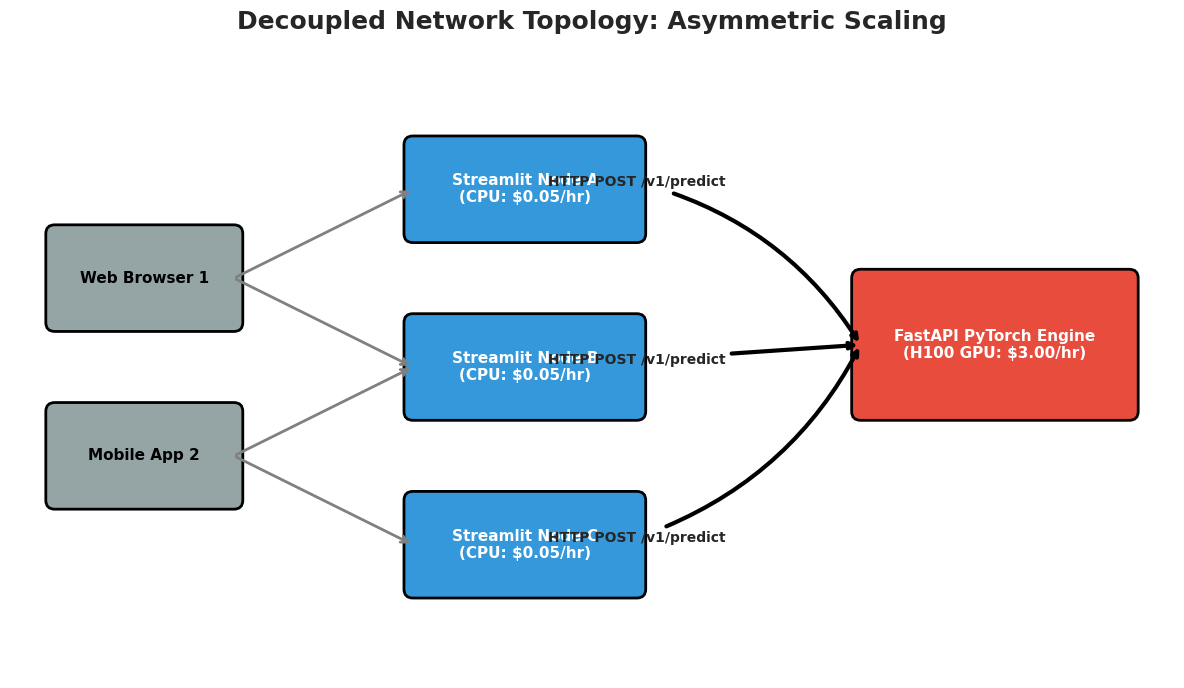


--- 💡 Engineering Insight ---
Look at the Network Arrows. The Frontends (Blue) handle all the messy HTML rendering, websocket management, and concurrent user tracking. When they need complex mathematics, they synthesize a unified REST payload and forward it to the single GPU server (Red).
If UI traffic spikes, Kubernetes can spin up 10 more Blue nodes for pennies. Because the Red node is protected by FastAPI's concurrency threadpools (Lesson 06), it acts as a massive centralized calculator serving all the Blue nodes simultaneously.


In [4]:
# Visualizing the Enterprise Topology
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Decoupled Network Topology: Asymmetric Scaling", fontsize=18, fontweight='bold')

# Turn off standard axes
ax.axis('off')

# Helper function to draw server nodes
def draw_node(ax, x, y, width, height, text, color, text_color="white"):
    rect = patches.FancyBboxPatch((x, y), width, height, boxstyle="round,pad=0.1", 
                                  linewidth=2, edgecolor='black', facecolor=color)
    ax.add_patch(rect)
    ax.text(x + width/2, y + height/2, text, ha='center', va='center', 
            fontsize=11, fontweight='bold', color=text_color)

# 1. Draw Clients (The Internet)
draw_node(ax, 0.5, 5, 2, 1, "Web Browser 1", "#95a5a6", "black")
draw_node(ax, 0.5, 3, 2, 1, "Mobile App 2", "#95a5a6", "black")

# 2. Draw CPU Frontend Nodes (Scaled 3x)
draw_node(ax, 4.5, 6, 2.5, 1, "Streamlit Node A\n(CPU: $0.05/hr)", "#3498db")
draw_node(ax, 4.5, 4, 2.5, 1, "Streamlit Node B\n(CPU: $0.05/hr)", "#3498db")
draw_node(ax, 4.5, 2, 2.5, 1, "Streamlit Node C\n(CPU: $0.05/hr)", "#3498db")

# 3. Draw GPU Backend Node (Scaled 1x)
draw_node(ax, 9.5, 4, 3, 1.5, "FastAPI PyTorch Engine\n(H100 GPU: $3.00/hr)", "#e74c3c")

# Draw Network Arrows (Client -> Frontend)
ax.annotate("", xy=(4.5, 6.5), xytext=(2.5, 5.5), arrowprops=dict(arrowstyle="->", lw=2, color="gray"))
ax.annotate("", xy=(4.5, 4.5), xytext=(2.5, 5.5), arrowprops=dict(arrowstyle="->", lw=2, color="gray"))
ax.annotate("", xy=(4.5, 4.5), xytext=(2.5, 3.5), arrowprops=dict(arrowstyle="->", lw=2, color="gray"))
ax.annotate("", xy=(4.5, 2.5), xytext=(2.5, 3.5), arrowprops=dict(arrowstyle="->", lw=2, color="gray"))

# Draw Network Arrows (Frontend -> Backend via REST)
ax.annotate("HTTP POST /v1/predict", xy=(9.5, 4.75), xytext=(7.0, 6.5), 
            arrowprops=dict(arrowstyle="->", lw=3, color="black", connectionstyle="arc3,rad=-0.2"), 
            fontsize=10, fontweight='bold', ha='center', va='bottom')

ax.annotate("HTTP POST /v1/predict", xy=(9.5, 4.75), xytext=(7.0, 4.5), 
            arrowprops=dict(arrowstyle="->", lw=3, color="black"), 
            fontsize=10, fontweight='bold', ha='center', va='bottom')

ax.annotate("HTTP POST /v1/predict", xy=(9.5, 4.75), xytext=(7.0, 2.5), 
            arrowprops=dict(arrowstyle="->", lw=3, color="black", connectionstyle="arc3,rad=0.2"), 
            fontsize=10, fontweight='bold', ha='center', va='bottom')

plt.xlim(0, 13)
plt.ylim(1, 8)
plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look at the Network Arrows. The Frontends (Blue) handle all the messy HTML rendering, websocket management, and concurrent user tracking. When they need complex mathematics, they synthesize a unified REST payload and forward it to the single GPU server (Red).")
print("If UI traffic spikes, Kubernetes can spin up 10 more Blue nodes for pennies. Because the Red node is protected by FastAPI's concurrency threadpools (Lesson 06), it acts as a massive centralized calculator serving all the Blue nodes simultaneously.")

## Real-World Use Case or Analogy:

Think of Decoupled Architecture like **A High-End Restaurant Hierarchy**:

* **The Monolith (The Food Truck)**: In a food truck, the person taking your credit card is the exact same person flipping the burgers on the grill. If 50 people line up to order, the cook has to stop flipping burgers to talk to every single customer. The cooking stops. The system is choked.
* **Decoupled Architecture (The Fine Dining Restaurant)**:
* **Streamlit (The Waiters)**: You hire 10 waiters (Cheap CPU nodes). Their only job is to render a nice experience, hand out menus, take orders, and talk to customers. They do not know how to cook.
* **FastAPI (The Master Chef)**: You hire 1 Master Chef (The Expensive GPU). The Chef stays in the kitchen.
* **The Network Bridge (The Order Ticket)**: When the waiter takes an order, they write it down on a standardized piece of paper (JSON payload) and clip it to the kitchen window (HTTP POST). The Chef reads it, cooks the steak, puts it in the window, and rings a bell. The waiter carries it back to the customer.
* If you get a massive rush of customers, you just hire 5 more waiters for the night. You don't need to build a second kitchen!